In [185]:
#importing necessary packages
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

**Task 1**

In [186]:
#Loading Image.
im1=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q1.jpeg",flags=cv.IMREAD_GRAYSCALE)
assert im1 is not None

In [187]:
#Function to Create Intensity Transformation Function based on given break points
def Intensity_Transform(c):
    parts = []
    for i in range(len(c) - 1):
        x1, y1 = c[i]
        x2, y2 = c[i + 1]
        # Ignore vertical sections
        if x1 == x2:
            continue
        # Values for x1, x1+1, ..., x2-1
        part = np.linspace(y1, y2, x2 - x1 + 1)[:-1]
        parts.append(part)
    # Add output value corresponding to x = 255
    parts.append(np.array([c[-1, 1]]))
    return np.concatenate(parts).astype('uint8')

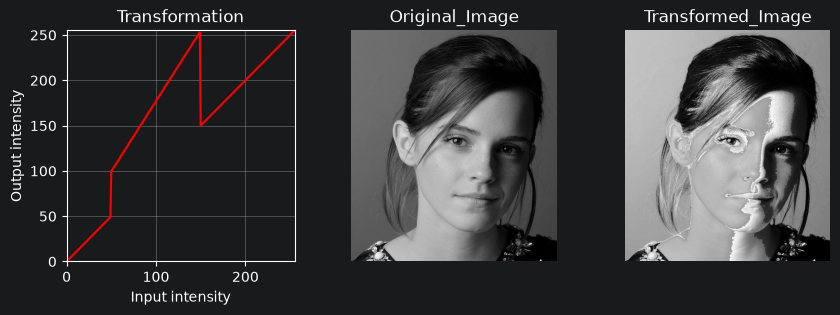

In [188]:
#Defining Intensity Transformation Function (Given Graph)
c = np.array([(0,0),(50,50), (50,100), (150,255), (150,150),(255,255)])
Transformation = Intensity_Transform(c)
Transformed_im = cv.LUT(im1, Transformation)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(10,3))
ax[0].plot(Transformation, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im1,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Transformed_Image')
ax[2].axis('off')
plt.show()

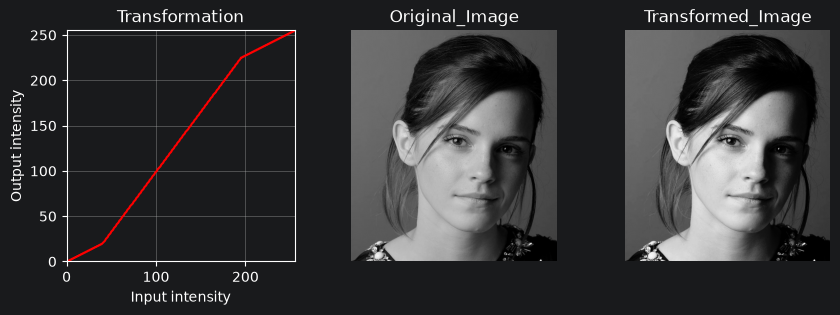

In [189]:
#Defining Intensity Transformation Function (Custom)
c_ = np.array([(0,0),(40,20),(195,225),(255,255)])
Transformation_ = Intensity_Transform(c_)
Transformed_im_ = cv.LUT(im1, Transformation_)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(10,3))
ax[0].plot(Transformation_, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im1,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im_,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Transformed_Image')
ax[2].axis('off')
plt.show()

*Discussion*

The piecewise intensity transformation selectively modifies different intensity ranges of the image. The steep section between approximately 50 and 150 expands the contrast of pixels within this range making facial details more distinguishable while the discontinuities produce abrupt changes in output intensity. The selected breakpoints therefore increase contrast in the desired regions while retaining the overall structure of the image. Several breakpoint configurations were considered, and the displayed transformation was selected because it provided visually pleasing results.

**Task 2**

*(a) Accentuating White Matter in Brain MRI Image*

In [190]:
#Loading Brain MRI Image.
im2=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q2.jpeg",flags=cv.IMREAD_GRAYSCALE)
assert im2 is not None

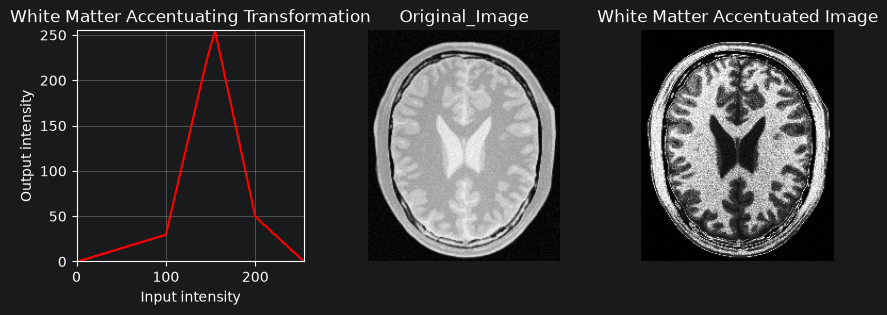

In [191]:
#Defining Break Points for Accentuating White Matter in Brain MRI Image
c_white = np.array([(0,0), (100,30), (145,220), (155,255),(200,50),(255,0)])
Transform_white = Intensity_Transform(c_white)
Transformed_im_white = cv.LUT(im2, Transform_white)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(10,3))
ax[0].plot(Transform_white, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('White Matter Accentuating Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im2,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im_white,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('White Matter Accentuated Image')
ax[2].axis('off')
plt.show()

*(b) Accentuating Gray Matter in Brain MRI Image*

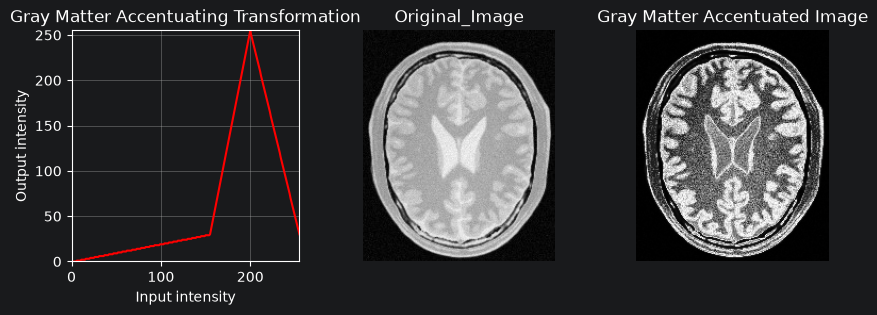

In [192]:
#Defining Break Points for Accentuating Gray Matter in Brain MRI Image
c_gray = np.array([(0,0),(155,30), (200,255), (255,30)])
Transform_gray = Intensity_Transform(c_gray)
Transformed_im_gray = cv.LUT(im2, Transform_gray)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(10,3))
ax[0].plot(Transform_gray, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Gray Matter Accentuating Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(im2,cmap='gray',vmin=0,vmax=255)
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(Transformed_im_gray,cmap='gray',vmin=0,vmax=255)
ax[2].set_title('Gray Matter Accentuated Image')
ax[2].axis('off')
plt.show()

*Discussion*

Different intensity ranges were emphasized for white and gray matter because the two tissues occupy different ranges in the image. For white matter, the transformation strongly increases the output around the selected intensity range(Peak at 155) while suppressing intensities outside it. For gray matter the peak of the transformation is shifted to a higher value(Peak at 200). These Trasformations make the corresponding tissue becomes more visible.

**Task 3**

*(a) Gamma Correction on Color Image For Gamma = 0.6*

In [193]:
#Loading Image.
im3 = cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q3.jpeg")
assert im3 is not None

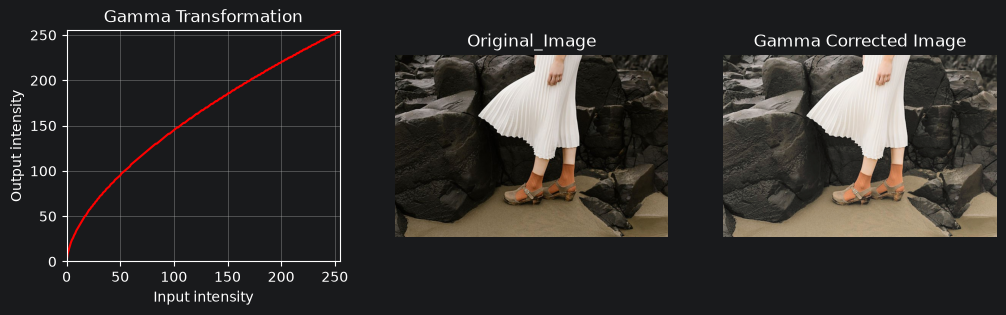

In [194]:
#Defining Gamma Value
gamma=0.6
#Converting Image to LAB Color Space
im3_lab = cv.cvtColor(im3, cv.COLOR_BGR2LAB)
#Extracting Luminance Channel
im3_l = im3_lab[:,:,0]
#Transformation Function for Gamma Correction
Gamma_Transformation = np.array([((i/255.0)**gamma)*255 for i in range(256)]).astype('uint8')
#Applying Gamma Correction to Luminance Channel
Transformed_im3 = cv.LUT(im3_l, Gamma_Transformation)
#Replacing Luminance Channel with Transformed Luminance Channel
im3_lab[:,:,0] = Transformed_im3
#Converting Image back to BGR Color Space
im3_final = cv.cvtColor(im3_lab, cv.COLOR_LAB2BGR)

#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(12,3))
ax[0].plot(Gamma_Transformation, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title('Gamma Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(cv.cvtColor(im3, cv.COLOR_BGR2RGB))
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(cv.cvtColor(im3_final, cv.COLOR_BGR2RGB))
ax[2].set_title('Gamma Corrected Image')
ax[2].axis('off')
plt.show()


*(b) Plotting Histogram of Original and Gamma Corrected Images*

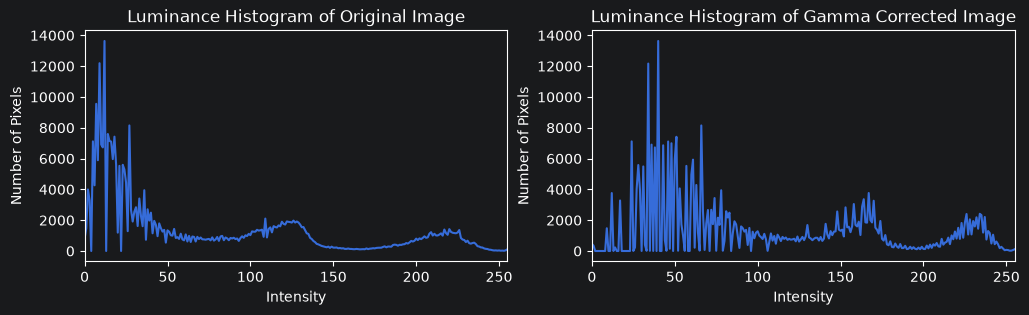

In [195]:
#Converting Original and Gamma Corrected Images to LAB Color Space To View Histograms of Luminance Channel
im3_= cv.cvtColor(im3, cv.COLOR_BGR2LAB)
im3_final_ = cv.cvtColor(im3_final, cv.COLOR_BGR2LAB)
#Calculating Histogram of Luminance Channel of Original and Gamma Corrected Images
original_histogram = cv.calcHist([im3_], [0], None, [256], [0, 256])
gamma_corrected_histogram = cv.calcHist([im3_final_], [0], None, [256], [0, 256])
#Plotting Histogram of Original and Gamma Corrected Images
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot(original_histogram)
ax[0].set_title('Luminance Histogram of Original Image')
ax[0].set_xlabel('Intensity')
ax[0].set_ylabel('Number of Pixels')
ax[0].set_xlim([0,255])
ax[1].plot(gamma_corrected_histogram)
ax[1].set_title('Luminance Histogram of Gamma Corrected Image')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Number of Pixels')
ax[1].set_xlim([0,255])
plt.show()

*Discussion*

A gamma value of 0.6 was choosen by comparing outputs for several values because this value increases low and mid luminance values causing the corrected image to appear brighter while maintaining the proper structure of the image. This is also visible in the luminance histogram where the distribution shifts toward higher intensity values after correction. Performing the transformation only on the L plane modifies brightness without directly changing the colour components.

**Task 4**

*(a) Loading and Splitting Image into HSV Planes*

In [196]:
#Loading Image
im4=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q4.jpeg")
assert im4 is not None
#Converting BGR to HSV
im4_hsv=cv.cvtColor(im4,cv.COLOR_BGR2HSV)
#splitting into seperate H,S,V arrays
im4_hue=im4_hsv[:,:,0]
im4_sat=im4_hsv[:,:,1]
im4_val=im4_hsv[:,:,2]

*(b),(c) Applying Transformation to Saturation Plane and Adjusting value a(a=0.6) to get a visually Pleasing Output*

In [197]:
a=0.6 #Setting Value a
sigma=70
#Defining Transformation Function
q4_Transformation=np.array([min(i + a*128*np.exp(-((i-128)**2)/(2*sigma**2)),255)for i in range(256)]).astype('uint8')
#Applying Transformation to Saturation Plane
im4_sat_transformed=cv.LUT(im4_sat,q4_Transformation)

*(d) Recombining the Layers*

In [198]:
#Replacing Saturation Array in original image with transformed array
im4_hsv[:,:,1]=im4_sat_transformed #now im4_hsv contains Saturation Transformed Image

*(e) Plotting Transformation, Original Image and Transformed Image*

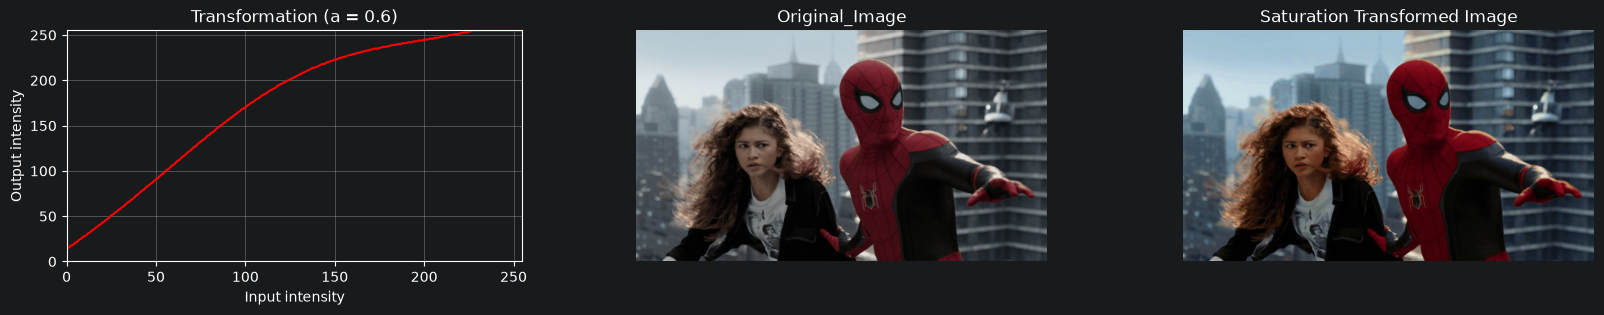

In [199]:
#Plotting Transformation Function and Original and Transformed Images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(20,3))
ax[0].plot(q4_Transformation, color='red')
ax[0].set_xlim(0, 255)
ax[0].set_ylim(0, 255)
ax[0].set_title(f'Transformation (a = {a})')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].grid()
ax[1].imshow(cv.cvtColor(im4, cv.COLOR_BGR2RGB))
ax[1].set_title('Original_Image')
ax[1].axis('off')
ax[2].imshow(cv.cvtColor(im4_hsv, cv.COLOR_HSV2RGB))
ax[2].set_title('Saturation Transformed Image')
ax[2].axis('off')
plt.show()

*Discussion*

A value of a=0.6 was selected experimentally as it increased colour vibrance without producing excessive saturation. The transformation produces its strongest increase around intermediate saturation values and has a smaller effect toward the extremes. Therefore moderately saturated colours are enhanced more strongly while already highly saturated colours are less likely to be clipped at 255.

**Task 5**

In [200]:
#Loading Image
im5=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q5.tif", flags=cv.IMREAD_GRAYSCALE)
assert im5 is not None

(np.float64(-0.5), np.float64(499.5), np.float64(499.5), np.float64(-0.5))

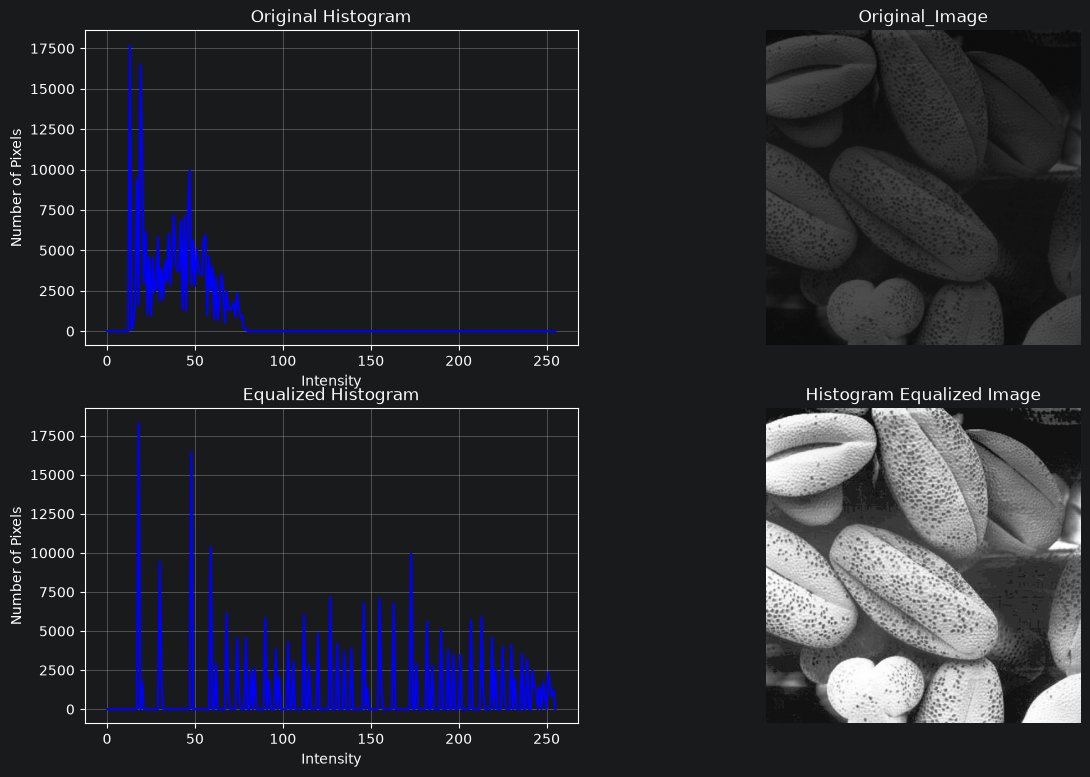

In [201]:
def Histogram_Equalization(image):
    # For 8-bit grayscale image
    L = 256
    # Image dimensions
    M, N = image.shape
    # Histogram
    hist = cv.calcHist([image],[0],None,[256],[0,256])
    # Cumulative distribution
    cdf = hist.cumsum()
    # Histogram equalization transformation
    Histogram_Eq_Transform = np.array([(L-1)/(M*N) * cdf[i] for i in range(256)]).astype('uint8')
    # Apply transformation
    equalized_image = cv.LUT(image,Histogram_Eq_Transform)
    return equalized_image, hist, Histogram_Eq_Transform

im5_equalized, hist, Histogram_Eq_Transform = Histogram_Equalization(im5)
hist_equalized = cv.calcHist([im5_equalized],[0],None,[256],[0,256])
#Plotting Original and Transformed Images With Original and Equalized Histograms
fig,ax = plt.subplots(nrows=2,ncols=2, figsize=(14,9))
ax[0][0].plot(hist, color='blue')
ax[0][0].set_title('Original Histogram')
ax[0][0].set_xlabel('Intensity')
ax[0][0].set_ylabel('Number of Pixels')
ax[0][0].grid()
ax[0][1].imshow(im5,cmap='gray',vmin=0,vmax=255)
ax[0][1].set_title('Original_Image')
ax[0][1].axis('off')
ax[1][0].plot(hist_equalized, color='blue')
ax[1][0].set_title('Equalized Histogram')
ax[1][0].set_xlabel('Intensity')
ax[1][0].set_ylabel('Number of Pixels')
ax[1][0].grid()
ax[1][1].imshow(im5_equalized,cmap='gray',vmin=0,vmax=255)
ax[1][1].set_title('Histogram Equalized Image')
ax[1][1].axis('off')


*Discussion*

The original histogram is concentrated mainly in a limited low intensity range which explains the low contrast of the original image. Histogram equalization maps the cumulative distribution over a wider portion of the available 0–255 intensity range. As a result the equalized image exhibits greater contrast and previously indistinct details become more visible. The equalized histogram is not perfectly uniform because histogram equalization redistributes discrete image intensity levels and does not guarantee an exactly flat histogram.

**Task 6**

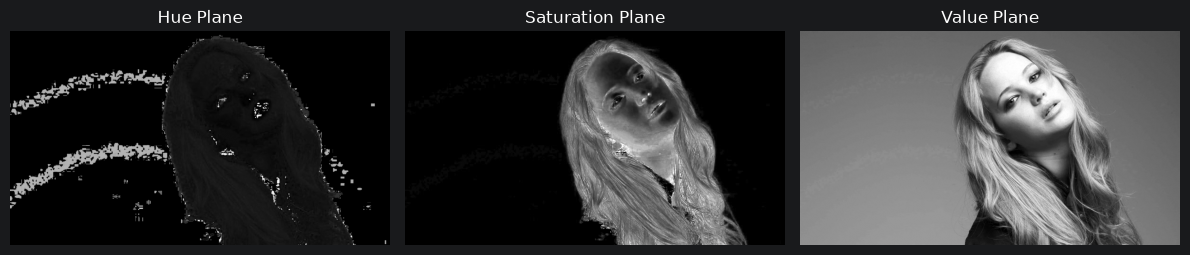

In [202]:
# Loading image
im6 = cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes\Assignments\images\q6.jpeg")
assert im6 is not None
# Convert BGR to HSV
im6_hsv = cv.cvtColor(im6, cv.COLOR_BGR2HSV)
H,S,V = cv.split(im6_hsv)
#Plots
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(H, cmap='gray')
ax[0].set_title('Hue Plane')
ax[0].axis('off')
ax[1].imshow(S, cmap='gray')
ax[1].set_title('Saturation Plane')
ax[1].axis('off')
ax[2].imshow(V, cmap='gray')
ax[2].set_title('Value Plane')
ax[2].axis('off')
plt.tight_layout()
plt.show()

*Since Saturation Plane shows clear seperation between foreground and background We can use S plane to create mask and extract foreground from Value plane as Histogram equalization should be carried out in V plane*

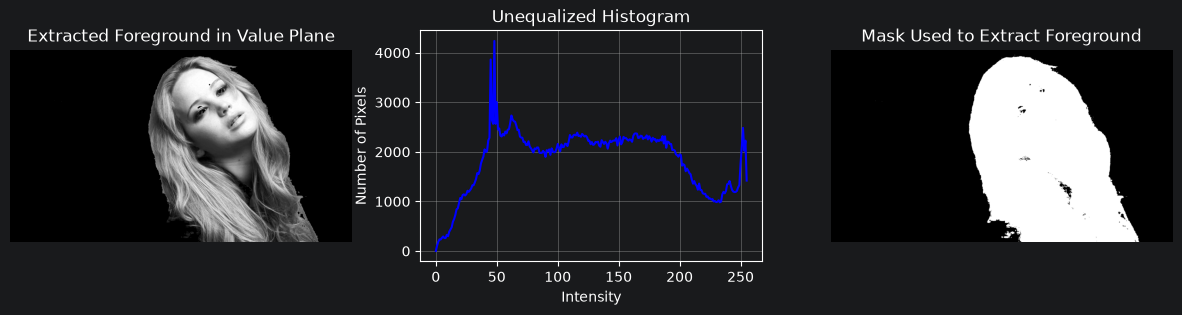

In [203]:
_, mask = cv.threshold(S,14,255,cv.THRESH_BINARY)
# Use bitwise_and to extract the foreground of V plane using the mask
foreground = cv.bitwise_and(V,V,mask=mask)
# Calculate the histogram of the Value channel
histogram = cv.calcHist([foreground], [0], mask, [256], [0, 256])
# Display the extracted foreground and Histogram
fig,ax=plt.subplots(1,3,figsize=(15, 3))
ax[0].imshow(foreground, cmap='gray')
ax[0].set_title('Extracted Foreground in Value Plane')
ax[0].axis('off')
ax[1].plot(histogram, color='blue')
ax[1].set_title('Unequalized Histogram')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Number of Pixels')
ax[1].grid()
ax[2].imshow(mask, cmap='gray',vmin=0,vmax=1)
ax[2].set_title('Mask Used to Extract Foreground')
ax[2].axis('off')
plt.show()

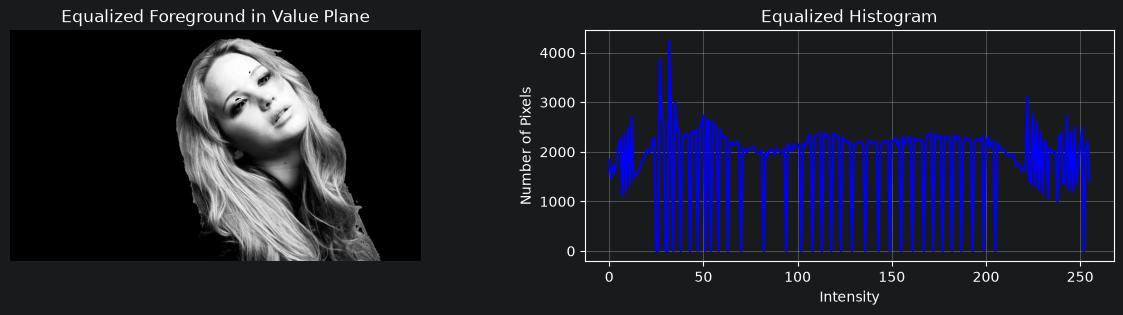

In [204]:
#Obtaining the cumulative sum of the histogram using np.cumsum.
cdf_6= np.cumsum(histogram)
# For 8-bit image
L = 256
# Number of foreground pixels
N_foreground = cv.countNonZero(mask)
#Since only foreground pixels are included in the histogram, the equalization transform is normalized using the number of foreground pixels rather than the total number of image pixels.
#Histogram equalization transform
Histogram_Eq_Transform_6 = np.array([(L-1)/N_foreground * cdf_6[i] for i in range(256)]).astype('uint8')
#Applying Transform to Foreground
foreground_equalized=cv.LUT(foreground,Histogram_Eq_Transform_6)
# Calculate the histogram of the Value channel
histogram_ = cv.calcHist([foreground_equalized], [0], mask, [256], [0, 256])
# Display the extracted foreground and Histogram
fig,ax=plt.subplots(1,2,figsize=(15, 3))
ax[0].imshow(foreground_equalized, cmap='gray')
ax[0].set_title('Equalized Foreground in Value Plane')
ax[0].axis('off')
ax[1].plot(histogram_, color='blue')
ax[1].set_title('Equalized Histogram')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Number of Pixels')
ax[1].grid()
plt.show()

*Since Foreground is equalized now we can add it back with background to produce Final Image where only the Foreground is equalized*

In [205]:
mask_inv = cv.bitwise_not(mask)
background = cv.bitwise_and(V,V,mask=mask_inv)
V_final = cv.add(foreground_equalized,background)
im6_final=im6_hsv.copy()
im6_final[:,:,2]=V_final

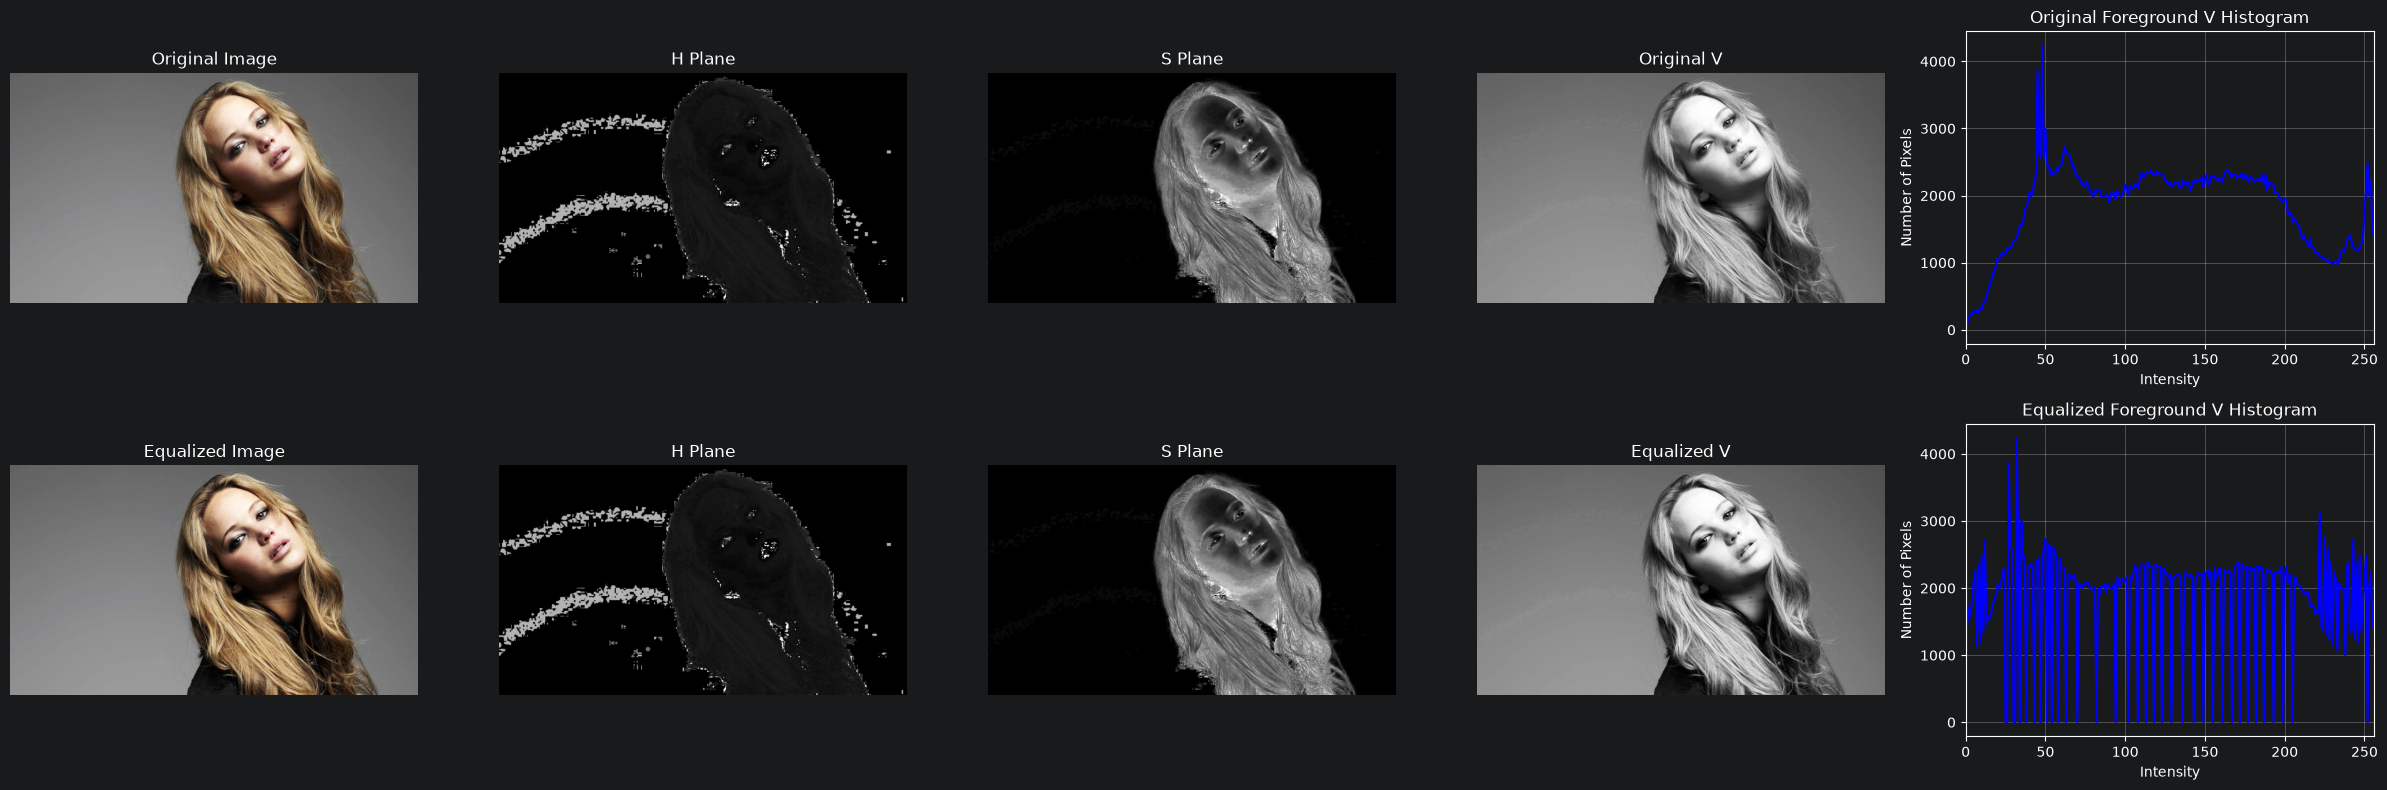

In [206]:
fig, ax = plt.subplots(2, 5, figsize=(24, 8))
# ---------------- ORIGINAL ----------------
ax[0,0].imshow(cv.cvtColor(im6, cv.COLOR_BGR2RGB))
ax[0,0].set_title('Original Image')
ax[0,0].axis('off')
ax[0,1].imshow(H, cmap='gray')
ax[0,1].set_title('H Plane')
ax[0,1].axis('off')
ax[0,2].imshow(S, cmap='gray')
ax[0,2].set_title('S Plane')
ax[0,2].axis('off')
ax[0,3].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[0,3].set_title('Original V')
ax[0,3].axis('off')
ax[0,4].plot(histogram, color='blue')
ax[0,4].set_title('Original Foreground V Histogram')
ax[0,4].set_xlabel('Intensity')
ax[0,4].set_ylabel('Number of Pixels')
ax[0,4].set_xlim([0,256])
ax[0,4].grid()
# ---------------- EQUALIZED ----------------
ax[1,0].imshow(cv.cvtColor(im6_final, cv.COLOR_HSV2RGB))
ax[1,0].set_title('Equalized Image')
ax[1,0].axis('off')
ax[1,1].imshow(H, cmap='gray')
ax[1,1].set_title('H Plane')
ax[1,1].axis('off')
ax[1,2].imshow(S, cmap='gray')
ax[1,2].set_title('S Plane')
ax[1,2].axis('off')
ax[1,3].imshow(V_final, cmap='gray', vmin=0, vmax=255)
ax[1,3].set_title('Equalized V')
ax[1,3].axis('off')
ax[1,4].plot(histogram_, color='blue')
ax[1,4].set_title('Equalized Foreground V Histogram')
ax[1,4].set_xlabel('Intensity')
ax[1,4].set_ylabel('Number of Pixels')
ax[1,4].set_xlim([0,256])
ax[1,4].grid()
plt.tight_layout()
plt.show()

*Discussion*

The saturation plane provides the clearest separation between the low saturation gray background and the foreground subject and was therefore used to obtain the binary mask. Histogram equalization was applied only to the V values of foreground pixels. The hue and saturation information and the original background were retained. The foreground histogram becomes distributed over a wider intensity range after equalization, increasing contrast in the subject while avoiding unnecessary modification of the background.

**Task 7**

*(a) Filtering Image using Filter2D*

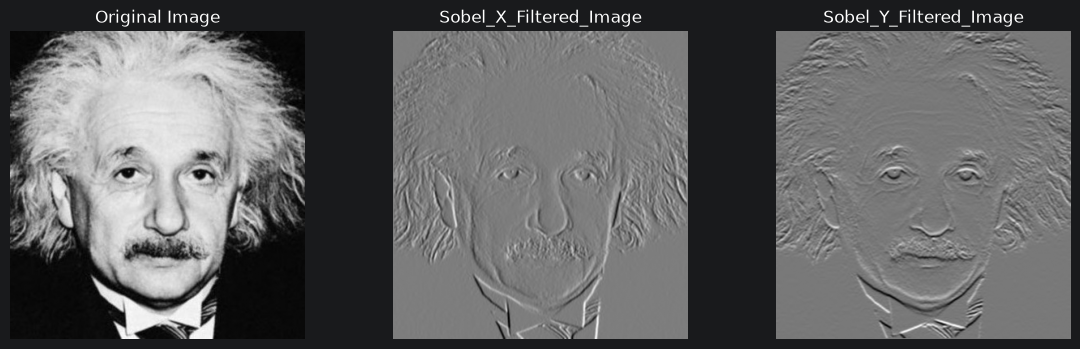

In [207]:
#Loading Image
im7 = cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q7.jpeg",flags=cv.IMREAD_GRAYSCALE)
assert im7 is not None
# Define the Sobel-X filter
sobel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
# Define the Sobel-Y filter
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])
# Apply the Sobel filter in the X direction
sobel_x_filtered = cv.filter2D(im7, cv.CV_64F, sobel_x)
# Apply the Sobel filter in the Y direction
sobel_y_filtered = cv.filter2D(im7, cv.CV_64F, sobel_y)
#plotting original, sobel-x filtered, sobel-y filtered images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].imshow(im7,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(sobel_x_filtered,cmap='gray')
ax[1].set_title('Sobel_X_Filtered_Image')
ax[1].axis('off')
ax[2].imshow(sobel_y_filtered,cmap='gray')
ax[2].set_title('Sobel_Y_Filtered_Image')
ax[2].axis('off')
plt.show()

*Discussion*

The Sobel X response emphasizes intensity changes in the horizontal image direction and therefore highlights predominantly vertical structures while Sobel-Y emphasizes changes in the vertical direction and highlights predominantly horizontal structures.

*(b) My own code to sobel filter the image*

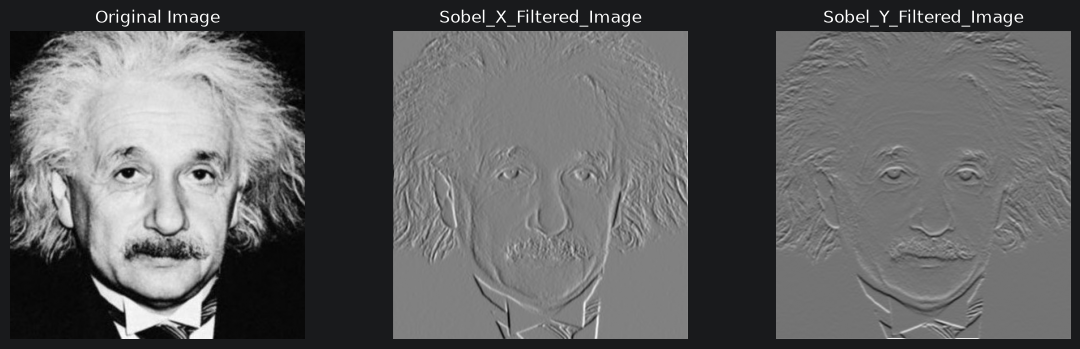

In [208]:
#Function to filter image
def Filter(image, filter):
    #Padding input image
    image_padded=np.pad(image,((1,1),(1,1)),'constant')
    M,N = image.shape
    filtered = np.zeros((M,N),dtype='float32')
    #Carrying out 2D Convolution
    for i in range(M):
        for j in range(N):
            value = np.sum(np.multiply(filter, image_padded[i:i + 3, j:j + 3]))
            filtered[i, j] = value
    return filtered
# Apply the Sobel filter in the X direction
sobel_x_filtered_custom = Filter(im7,sobel_x)
# Apply the Sobel filter in the Y direction
sobel_y_filtered_custom = Filter(im7,sobel_y)
#plotting original, sobel-x filtered, sobel-y filtered images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].imshow(im7,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(sobel_x_filtered_custom,cmap='gray')
ax[1].set_title('Sobel_X_Filtered_Image')
ax[1].axis('off')
ax[2].imshow(sobel_y_filtered_custom,cmap='gray')
ax[2].set_title('Sobel_Y_Filtered_Image')
ax[2].axis('off')
plt.show()


*(c) Applying Sobel Filter Using Property*

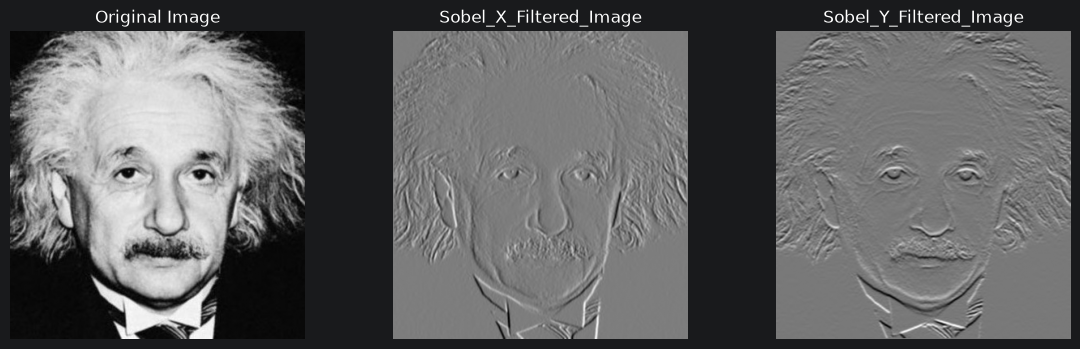

In [209]:
# Sobel x filter seperated into two parts
sobel_x_vertical = np.array([[1], [2], [1]])
sobel_x_horizontal = np.array([[1, 0, -1]])
# Sobel y filter seperated into two parts
sobel_y_vertical = np.array([[1], [0], [-1]])
sobel_y_horizontal = np.array([[1, 2, 1]])
# Apply the vertical and horizontal filters iteratively
x_intermediate = cv.filter2D(im7, cv.CV_64F, sobel_x_vertical)
sobel_x_filtered_iterative = cv.filter2D(x_intermediate, cv.CV_64F, sobel_x_horizontal)
y_intermediate = cv.filter2D(im7, cv.CV_64F, sobel_y_vertical)
sobel_y_filtered_iterative = cv.filter2D(y_intermediate, cv.CV_64F, sobel_y_horizontal)
#plotting original, sobel-x filtered, sobel-y filtered images
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(14,4))
ax[0].imshow(im7,cmap='gray',vmin=0,vmax=255)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(sobel_x_filtered_iterative,cmap='gray')
ax[1].set_title('Sobel_X_Filtered_Image')
ax[1].axis('off')
ax[2].imshow(sobel_y_filtered_iterative ,cmap='gray')
ax[2].set_title('Sobel_Y_Filtered_Image')
ax[2].axis('off')
plt.show()

*Discussion*

The manually implemented convolution produces visually similar Sobel responses to cv.filter2D confirming that the neighbourhood operation has been implemented correctly. The Sobel kernel is also separable the kernel can be represented as consecutive one dimensional smoothing and derivative operations. This reduces the number of operations required per pixel while producing essentially the same filtering result.

**Task 8**

In [210]:
#Function to Zoom Given image,method and scale
def Zoom(image, method, scale):
    if method == 'NN':
        return cv.resize(image,None,fx=scale,fy=scale, interpolation=cv.INTER_NEAREST)
    elif method == 'bilinear':
        return cv.resize(image,None,fx=scale,fy=scale, interpolation=cv.INTER_LINEAR)
def Zoom1(image, method, reference):
    height, width = reference.shape[:2]
    #instead of the defining zoom factor the small image will be zoomed to match the reference image dimentions
    #Adjusted because complications occured when using zoom factor in image 3 as dimention mismatch occured
    if method == 'NN':
        return cv.resize(image,(width,height), interpolation=cv.INTER_NEAREST)
    elif method == 'bilinear':
        return cv.resize(image,(width,height), interpolation=cv.INTER_LINEAR)
#Function to calculate normalized Sum of Squared Differences between two images
def normalized_SSD(image1, image2):
    if image1.shape != image2.shape:
        raise ValueError("Images must have the same dimensions")
    image1 = image1.astype(np.float32)
    image2 = image2.astype(np.float32)
    return np.sum((image1-image2)**2) / image1.size

*Image 1*

In [211]:
#loading image
im8_1=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_1.png")
assert im8_1 is not None
im8_1_small=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_1_small.png")
assert im8_1_small is not None
#Zooming images
im8_1_NN=Zoom(im8_1_small,method="NN",scale=4)
im8_1_bilinear=Zoom(im8_1_small,method="bilinear",scale=4)
#Calculating Normalized Sum of Squared Differences
im8_1_NN_SSD=normalized_SSD(im8_1,im8_1_NN)
im8_1_bilinear_SSD=normalized_SSD(im8_1,im8_1_bilinear)
#Printing Results
print(f'Normalized Sum of Squared Differences for Nearest Neighbour : {im8_1_NN_SSD:.5f}')
print(f'Normalized Sum of Squared Differences for Bilinear Imterpolation : {im8_1_bilinear_SSD:.5f}')

Normalized Sum of Squared Differences for Nearest Neighbour : 136.26904
Normalized Sum of Squared Differences for Bilinear Imterpolation : 115.09190


*Image 2*


In [212]:
#loading image
im8_2=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_2.png")
assert im8_2 is not None
im8_2_small=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_2_small.png")
assert im8_2_small is not None
#Zooming images
im8_2_NN=Zoom(im8_2_small,method="NN",scale=4)
im8_2_bilinear=Zoom(im8_2_small,method="bilinear",scale=4)
#Calculating Normalized Sum of Squared Differences
im8_2_NN_SSD=normalized_SSD(im8_2,im8_2_NN)
im8_2_bilinear_SSD=normalized_SSD(im8_2,im8_2_bilinear)
#Printing Results
print(f'Normalized Sum of Squared Differences for Nearest Neighbour : {im8_2_NN_SSD:.5f}')
print(f'Normalized Sum of Squared Differences for Bilinear Imterpolation : {im8_2_bilinear_SSD:.5f}')

Normalized Sum of Squared Differences for Nearest Neighbour : 26.44609
Normalized Sum of Squared Differences for Bilinear Imterpolation : 18.34592


*Image 3*

In [213]:
#loading image
im8_3=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_3.png")
assert im8_3 is not None
im8_3_small=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_3_small.png")
assert im8_3_small is not None
#Zooming images
im8_3_NN=Zoom1(im8_3_small,method="NN",reference=im8_3)
im8_3_bilinear=Zoom1(im8_3_small,method="bilinear",reference=im8_3)
#Calculating Normalized Sum of Squared Differences
im8_3_NN_SSD=normalized_SSD(im8_3,im8_3_NN)
im8_3_bilinear_SSD=normalized_SSD(im8_3,im8_3_bilinear)
#Printing Results
print(f'Normalized Sum of Squared Differences for Nearest Neighbour : {im8_3_NN_SSD:.5f}')
print(f'Normalized Sum of Squared Differences for Bilinear Imterpolation : {im8_3_bilinear_SSD:.5f}')

Normalized Sum of Squared Differences for Nearest Neighbour : 67.58167
Normalized Sum of Squared Differences for Bilinear Imterpolation : 49.54620


*Image 4*

In [214]:
#loading image
im8_4=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_4.jpg")
assert im8_4 is not None
im8_4_small=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q8_4_small.jpg")
assert im8_4_small is not None
#Zooming images
im8_4_NN=Zoom1(im8_4_small,method="NN",reference=im8_4)
im8_4_bilinear=Zoom1(im8_4_small,method="bilinear",reference=im8_4)
#Calculating Normalized Sum of Squared Differences
im8_4_NN_SSD=normalized_SSD(im8_4,im8_4_NN)
im8_4_bilinear_SSD=normalized_SSD(im8_4,im8_4_bilinear)
#Printing Results
print(f'Normalized Sum of Squared Differences for Nearest Neighbour : {im8_4_NN_SSD:.5f}')
print(f'Normalized Sum of Squared Differences for Bilinear Imterpolation : {im8_4_bilinear_SSD:.5f}')

Normalized Sum of Squared Differences for Nearest Neighbour : 238.02815
Normalized Sum of Squared Differences for Bilinear Imterpolation : 222.93950


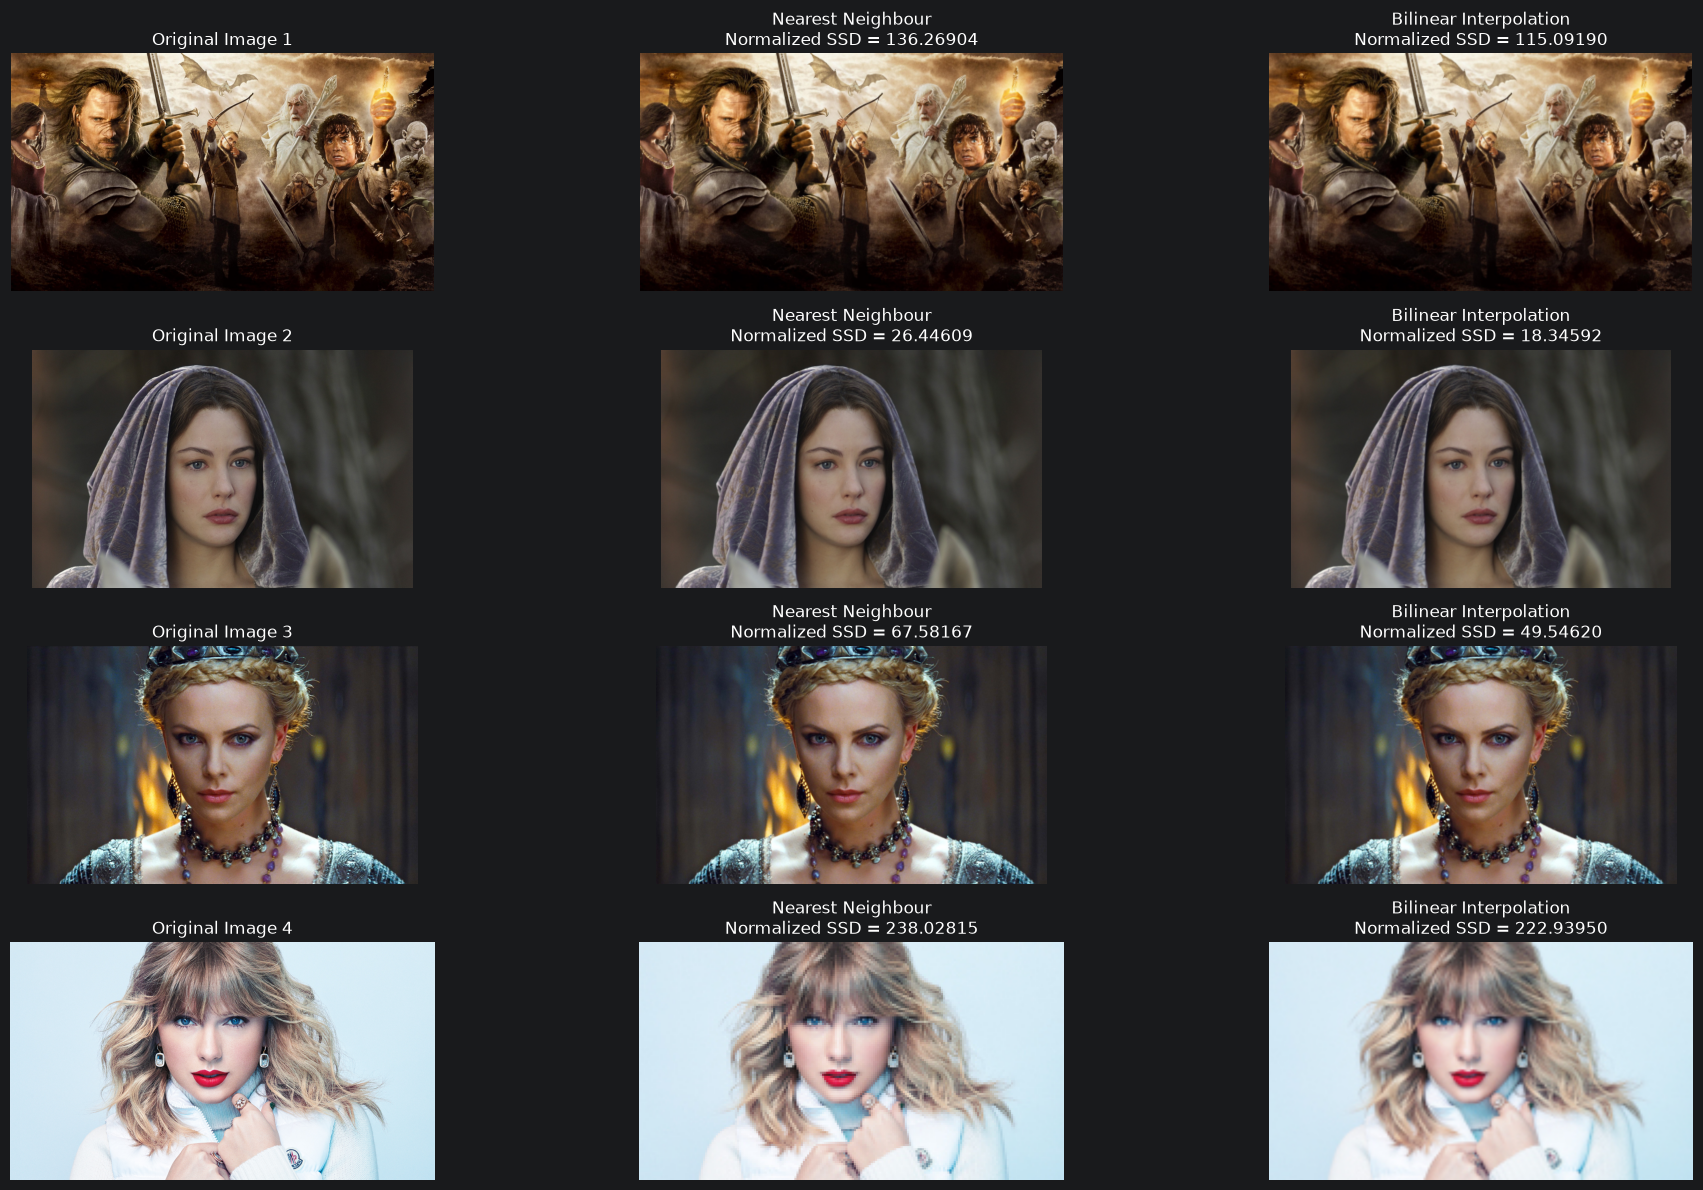

In [215]:
fig, ax = plt.subplots(nrows=4,ncols=3,figsize=(20, 12))
# ---------------- Image Set 1 ----------------
ax[0,0].imshow(cv.cvtColor(im8_1, cv.COLOR_BGR2RGB))
ax[0,0].set_title('Original Image 1')
ax[0,0].axis('off')
ax[0,1].imshow(cv.cvtColor(im8_1_NN, cv.COLOR_BGR2RGB))
ax[0,1].set_title(f'Nearest Neighbour\nNormalized SSD = {im8_1_NN_SSD:.5f}')
ax[0,1].axis('off')
ax[0,2].imshow(cv.cvtColor(im8_1_bilinear, cv.COLOR_BGR2RGB))
ax[0,2].set_title(f'Bilinear Interpolation\nNormalized SSD = {im8_1_bilinear_SSD:.5f}')
ax[0,2].axis('off')
# ---------------- Image Set 2 ----------------
ax[1,0].imshow(cv.cvtColor(im8_2, cv.COLOR_BGR2RGB))
ax[1,0].set_title('Original Image 2')
ax[1,0].axis('off')
ax[1,1].imshow(cv.cvtColor(im8_2_NN, cv.COLOR_BGR2RGB))
ax[1,1].set_title(f'Nearest Neighbour\nNormalized SSD = {im8_2_NN_SSD:.5f}')
ax[1,1].axis('off')
ax[1,2].imshow(cv.cvtColor(im8_2_bilinear, cv.COLOR_BGR2RGB))
ax[1,2].set_title(f'Bilinear Interpolation\nNormalized SSD = {im8_2_bilinear_SSD:.5f}')
ax[1,2].axis('off')
# ---------------- Image Set 3 ----------------
ax[2,0].imshow(cv.cvtColor(im8_3, cv.COLOR_BGR2RGB))
ax[2,0].set_title('Original Image 3')
ax[2,0].axis('off')
ax[2,1].imshow(cv.cvtColor(im8_3_NN, cv.COLOR_BGR2RGB))
ax[2,1].set_title(f'Nearest Neighbour\nNormalized SSD = {im8_3_NN_SSD:.5f}')
ax[2,1].axis('off')
ax[2,2].imshow(cv.cvtColor(im8_3_bilinear, cv.COLOR_BGR2RGB))
ax[2,2].set_title(f'Bilinear Interpolation\nNormalized SSD = {im8_3_bilinear_SSD:.5f}')
ax[2,2].axis('off')
# ---------------- Image Set 4 ----------------
ax[3,0].imshow(cv.cvtColor(im8_4, cv.COLOR_BGR2RGB))
ax[3,0].set_title('Original Image 4')
ax[3,0].axis('off')
ax[3,1].imshow(cv.cvtColor(im8_4_NN, cv.COLOR_BGR2RGB))
ax[3,1].set_title(f'Nearest Neighbour\nNormalized SSD = {im8_4_NN_SSD:.5f}')
ax[3,1].axis('off')
ax[3,2].imshow(cv.cvtColor(im8_4_bilinear, cv.COLOR_BGR2RGB))
ax[3,2].set_title(f'Bilinear Interpolation\nNormalized SSD = {im8_4_bilinear_SSD:.5f}')
ax[3,2].axis('off')
plt.tight_layout()
plt.show()

*Discussion*

Bilinear interpolation gives a lower normalized SSD than nearest neighbour interpolation for all four test images indicating that it reconstructs the original images more accurately. Nearest neighbour interpolation simply replicates the value of the closest source pixel and therefore tends to produce discrete transitions, whereas bilinear interpolation estimates each new pixel from neighbouring samples and produces smoother intensity transitions. The amount of improvement varies among the images because the reconstruction error also depends on image content particularly the amount of texture, detail and high frequency variation.

**Task 9**

*(a) Segmenting Image using GrabCut*

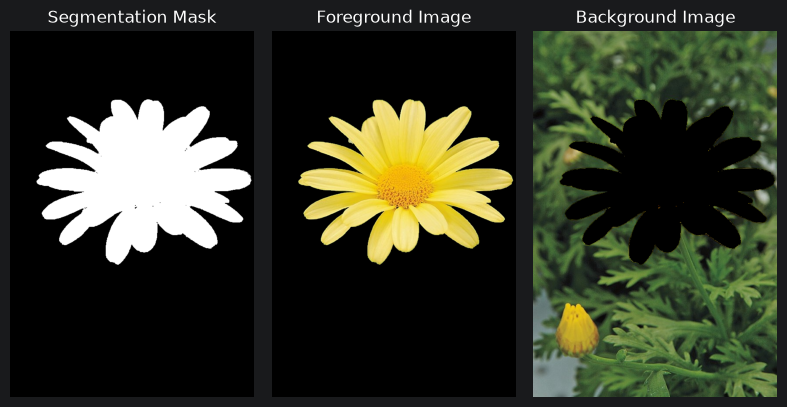

In [216]:
#Loading Image
im9=cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes/Assignments/images/q9.jpeg")
assert im9 is not None
mask = np.zeros(im9.shape[:2],np.uint8)
bg_Model = np.zeros((1,65),np.float64)
fg_Model = np.zeros((1,65),np.float64)
rect = (50,100,550,490)
cv.grabCut(im9,mask,rect,bg_Model,fg_Model,5,cv.GC_INIT_WITH_RECT)
mask_ = np.where((mask==2)|(mask==0),0,1).astype('uint8')
# Extract the foreground by multiplying the mask with the image
foreground = im9 * mask_[:, :, np.newaxis]
# Extract the background by subtracting the foreground from the original image
background = cv.subtract(im9, foreground)
# Show the results
fig, axs = plt.subplots(1, 3, figsize=(8, 4))
axs[0].imshow(mask_, cmap='gray')
axs[0].set_title('Segmentation Mask')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
axs[1].set_title('Foreground Image')
axs[1].axis('off')
axs[2].imshow(cv.cvtColor(background, cv.COLOR_BGR2RGB))
axs[2].set_title('Background Image')
axs[2].axis('off')
plt.tight_layout()
plt.show()

*Discussion*

GrabCut successfully separates the main flower from most of the surrounding background by iteratively modelling foreground and background colour distributions. The binary mask allows the foreground and background to be processed independently.

*(b)Producing Enhanced Image with Substantially blurred Background*

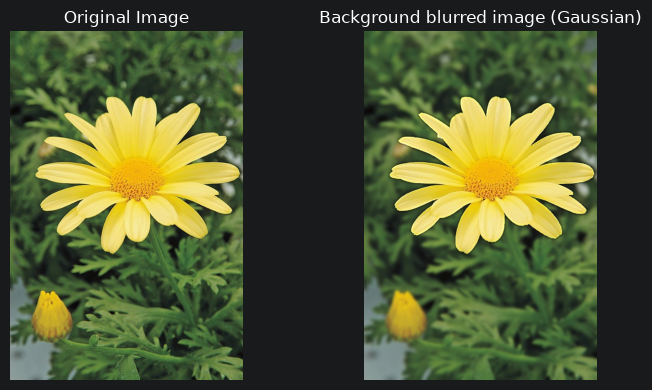

In [217]:
# Applying Gaussian blur to the background
background_blurred = cv.GaussianBlur(background, (35,35), 3)
# Join image
im9_final= cv.add(foreground, background_blurred)
# Plotting Results
fig, axs = plt.subplots(1, 2, figsize=(8,4))
axs[0].imshow(cv.cvtColor(im9, cv.COLOR_BGR2RGB))
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(im9_final, cv.COLOR_BGR2RGB))
axs[1].set_title('Background blurred image (Gaussian)')
axs[1].axis('off')
plt.tight_layout()
plt.show()

*Discussion*

Applying a large Gaussian kernel to the extracted background suppresses background detail and increases visual emphasis on the sharply extracted flower.

*(c) Why is the background just beyond the edge of the flower quite dark in the enhanced image?*

The dark region just outside the flower boundary is caused because the background was extracted and then blurred. When the foreground flower is removed foreground pixels are replaced by zeros creating a black flower shaped region in the background image. Now when the Background is Blurred using Gaussian blurring, pixels near the flower edge are computed as weighted averages of neighbouring pixels. Since some of those neighbouring pixels are zero valued as they were removed when extracting background seperately the average intensity near the boundary is reduced. As a result the background just beyond the edge of the flower looks quite dark in the enhanced image.

**Task 10**

*(a) Smoothing Images*

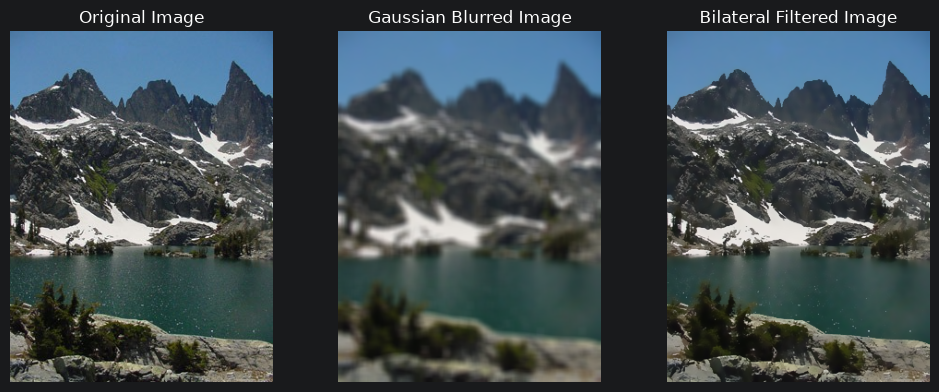

In [218]:
# Load image
im10 = cv.imread(filename="D:\EN3160 - Image Procesing and Machine Vision Codes\Assignments\images\q10.jpeg")
assert im10 is not None
# Parameters
d = 9
sigma_s = 5
sigma_r = 50
# Gaussian filtering
Gaussian_im = cv.GaussianBlur(im10, (d, d), sigma_s)
# Bilateral filtering
Bilateral_im = cv.bilateralFilter(im10,d=d,sigmaColor=sigma_r,sigmaSpace=sigma_s)
# Plotting Original, Gaussian Blurred, Bilateral Filtered Images
fig, ax = plt.subplots(1, 3, figsize=(10,4))
ax[0].imshow(cv.cvtColor(im10, cv.COLOR_BGR2RGB))
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(cv.cvtColor(Gaussian_im, cv.COLOR_BGR2RGB))
ax[1].set_title('Gaussian Blurred Image')
ax[1].axis('off')
ax[2].imshow(cv.cvtColor(Bilateral_im, cv.COLOR_BGR2RGB))
ax[2].set_title('Bilateral Filtered Image')
ax[2].axis('off')
plt.tight_layout()
plt.show()

*Discussion*

Although both filters reduce local intensity variation the Gaussian filter determines weights only from spatial distance and as a result smooths across edges. The bilateral filter additionally reduces the contribution of neighbouring pixels whose colour/intensity differs significantly from the centre pixel allowing regions such as the lake and sky to be smoothed while maintaining the mountain and lake shore boundaries.

*(b) Implementing Bilateral Filter*

In [219]:
def Bilateral_Filter(image, d, sigma_s, sigma_r):
    radius = d // 2
    image_float = image.astype(np.float64)
    padded = cv.copyMakeBorder(image_float,radius, radius,radius, radius,cv.BORDER_REFLECT)
    M, N, C = image.shape
    output = np.zeros_like(image_float)
    for i in range(M):
        for j in range(N):
            center = padded[i + radius, j + radius]
            weighted_sum = np.zeros(3)
            weight_sum = 0
            for m in range(-radius, radius + 1):
                for n in range(-radius, radius + 1):
                    neighbour = padded[i + radius + m,j + radius + n]
                    # Spatial Gaussian
                    spatial_weight = np.exp(-(m**2 + n**2) /(2 * sigma_s**2))
                    # Intensity/color distance
                    intensity_distance = np.sum((neighbour - center)**2)
                    # Range Gaussian
                    range_weight = np.exp(-intensity_distance /(2 * sigma_r**2))
                    weight = spatial_weight * range_weight
                    weighted_sum += weight * neighbour
                    weight_sum += weight
            output[i, j] = weighted_sum / weight_sum
    return np.clip(output, 0, 255).astype('uint8')
def MSE(image1, image2):
    image1 = image1.astype(np.float64)
    image2 = image2.astype(np.float64)
    return np.mean((image1 - image2)**2)

In [220]:
Manual_Bilateral = Bilateral_Filter(im10,d=9,sigma_s=5,sigma_r=50)
OpenCV_Bilateral = cv.bilateralFilter(im10,d=9,sigmaColor=50,sigmaSpace=5)

In [221]:
mse = MSE(Manual_Bilateral, OpenCV_Bilateral)
print("MSE between manual and OpenCV bilateral filters =", mse)

MSE between manual and OpenCV bilateral filters = 17.657796244998462


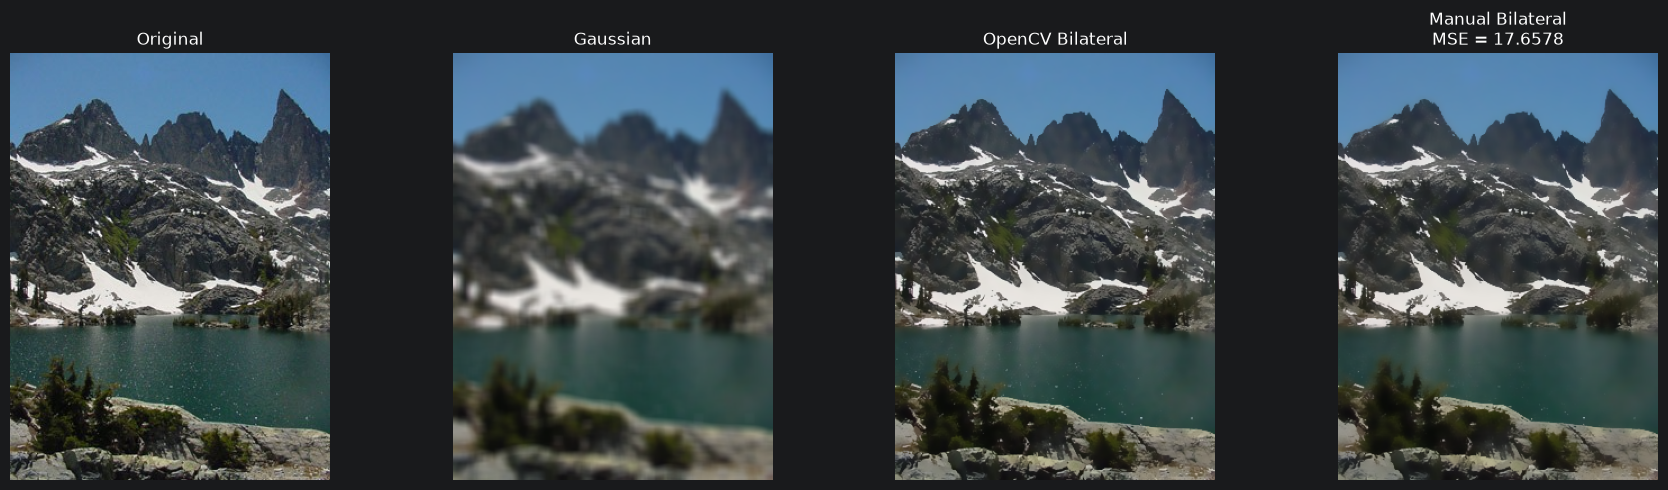

In [222]:
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(cv.cvtColor(im10, cv.COLOR_BGR2RGB))
ax[0].set_title('Original')
ax[0].axis('off')
ax[1].imshow(cv.cvtColor(Gaussian_im, cv.COLOR_BGR2RGB))
ax[1].set_title('Gaussian')
ax[1].axis('off')
ax[2].imshow(cv.cvtColor(OpenCV_Bilateral, cv.COLOR_BGR2RGB))
ax[2].set_title('OpenCV Bilateral')
ax[2].axis('off')
ax[3].imshow(cv.cvtColor(Manual_Bilateral, cv.COLOR_BGR2RGB))
ax[3].set_title(f'Manual Bilateral\nMSE = {mse:.4f}')
ax[3].axis('off')
plt.tight_layout()
plt.show()

*Discussion*

The manually implemented bilateral filter closely matches OpenCV’s result. Both methods smooth small intensity variations while preserving edges because the filter weights depend on both spatial distance and intensity difference. Compared with Gaussian filtering, edge blurring is reduced. The small MSE between the manual and OpenCV outputs confirms that the manual implementation produces a similar result while minor differences may arise from border handling and numerical implementation details.